# Track A — A2 모델 변수 중요도 분석 (track_a_02)

담당: 김태헌 | 선행 노트북: track_a_01

## 목적

Track B의 H7("대안변수는 기존정보를 대체하지 않고 보완한다")에 대응하는 분석은 Track A
구조상 성립하지 않는다 — A2 자체가 이미 "대안정보만"으로 이루어진 모델이라 비교 대상인
"기존정보 모델"이 따로 없기 때문이다. 대신 이 노트북은 **A2의 10개 공식 피처가 각각
얼마나 기여하는지, 특정 변수 한두 개에 예측력이 쏠려있진 않은지**를 SHAP으로 확인한다.
이건 Track B의 H8(대안변수 48개 전부 단독 유의미)과 더 가까운 성격의 검증이다.

## 방법

track_a_01의 CV는 out-of-fold 성능 평가용이라 단일 모델 객체가 남지 않는다. 이 노트북은
해석용으로 **전체 68,677명에 대해 다운샘플 50:1 × 5앙상블을 다시 학습**하고(성능 재평가가
목적이 아니라 SHAP 계산용), 5개 모델의 SHAP 값을 평균해서 변수 중요도를 낸다.

## 0. 환경 설정

In [5]:
%pip install lightgbm shap

Note: you may need to restart the kernel to use updated packages.


In [6]:
# pip install lightgbm shap

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import lightgbm as lgb
import shap

RANDOM_STATE = 42
handoff_path = r'C:\Users\tehun\Desktop\multicamp\project\creditscore\personalCB'

LGB_PARAMS = dict(
    max_depth=2, num_leaves=4, min_child_samples=20,
    n_estimators=200, learning_rate=0.05,
    objective='binary', verbose=-1,
)
DOWNSAMPLE_RATIO = 50
N_ENSEMBLE = 5

FEATURES_A2 = [
    'AL012G005_prev', 'AL012G011_prev', 'AL012G019_prev',
    'DELTA_AL012G005_prev', 'DELTA_AL012G011_prev', 'DELTA_AL012G019_prev',
    'U81301010_prev', 'U81305010_prev', 'U81306010_prev',
    'AS120G001_prev',
]


## 1. 데이터 로드 + 해석용 앙상블 학습 (F2, 공식 모델)

In [7]:
df_a2 = pd.read_csv(f'{handoff_path}/track_a_train_A2_v2.csv')
delta_cols = [c for c in df_a2.columns if c.startswith('DELTA_')]
df_a2[delta_cols] = df_a2[delta_cols].fillna(0)

X = df_a2[FEATURES_A2]
y = df_a2['TARGET_24M']

pos_idx = y[y == 1].index
neg_idx_all = y[y == 0].index
n_neg_sample = min(len(neg_idx_all), len(pos_idx) * DOWNSAMPLE_RATIO)

models = []
for e in range(N_ENSEMBLE):
    rng = np.random.RandomState(RANDOM_STATE + e)
    neg_sample = rng.choice(neg_idx_all, size=n_neg_sample, replace=False)
    train_idx = np.concatenate([pos_idx.values, neg_sample])
    Xe, ye = X.loc[train_idx], y.loc[train_idx]
    model = lgb.LGBMClassifier(**LGB_PARAMS, random_state=RANDOM_STATE + e)
    model.fit(Xe, ye)
    models.append(model)

print(f"{len(models)}개 모델 학습 완료 (해석용, 전체 {len(X)}명 기반)")


5개 모델 학습 완료 (해석용, 전체 68677명 기반)


## 2. SHAP 값 계산 (5개 모델 평균)

In [8]:
sample_n = min(10000, len(X))
X_sample = X.sample(sample_n, random_state=RANDOM_STATE)

shap_values_list = []
for model in models:
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_sample)
    if isinstance(sv, list):  # 일부 lightgbm 버전은 [neg, pos] 리스트로 반환
        sv = sv[1]
    shap_values_list.append(sv)

shap_avg = np.mean(shap_values_list, axis=0)
importance = pd.Series(np.abs(shap_avg).mean(axis=0), index=FEATURES_A2).sort_values(ascending=False)

print("A2 공식 피처 10개 — SHAP 중요도 순위:")
importance


A2 공식 피처 10개 — SHAP 중요도 순위:


AS120G001_prev          0.445331
U81301010_prev          0.200957
U81306010_prev          0.166646
AL012G019_prev          0.128289
AL012G005_prev          0.109981
AL012G011_prev          0.104187
DELTA_AL012G005_prev    0.059129
DELTA_AL012G019_prev    0.039317
DELTA_AL012G011_prev    0.007028
U81305010_prev          0.006594
dtype: float64

## 3. 시각화 + 저장

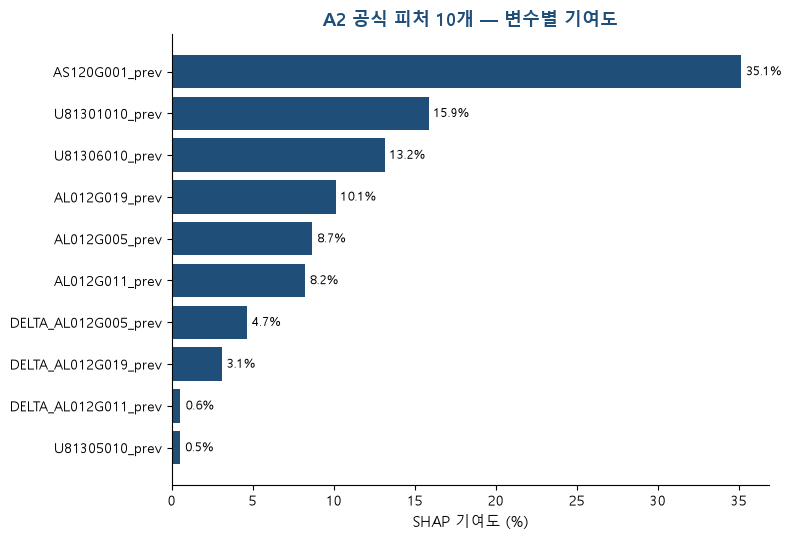

저장 완료: track_a_shap_importance.csv, 발표자료/trackA_02_변수중요도.png


In [9]:
import matplotlib.pyplot as plt
import os

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

NAVY = '#1F4E79'
importance_pct = (importance / importance.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.barh(importance_pct.index[::-1], importance_pct.values[::-1], color=NAVY)
for b, v in zip(bars, importance_pct.values[::-1]):
    ax.text(v + 0.3, b.get_y() + b.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('SHAP 기여도 (%)', fontsize=11)
ax.set_title('A2 공식 피처 10개 — 변수별 기여도', fontsize=13, fontweight='bold', color=NAVY)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()

output_dir = os.path.join(handoff_path, '발표자료')
os.makedirs(output_dir, exist_ok=True)
fig.savefig(os.path.join(output_dir, 'trackA_02_변수중요도.png'), dpi=300, bbox_inches='tight')
plt.show()

importance_pct.to_csv(f'{handoff_path}/track_a_shap_importance.csv', encoding='utf-8-sig')
print("저장 완료: track_a_shap_importance.csv, 발표자료/trackA_02_변수중요도.png")
